# 第19课 · 🎨 矩阵变换图解 — 旋转、缩放、剪切的动态视觉演示

> 视觉语言来自 **《The Art of Linear Algebra》**(Hiranabe & Strang)。

用 `laviz` 把矩阵/向量（vector）运算画成图，建立「矩阵×向量 = 列的线性组合」的空间直觉。Aurora 的 mel 滤波器矩阵 `M @ stft` 和 DFT 矩阵 `W @ x` 都是这张图的直接实例。

**学习目标**
1. 用 `laviz` 的 `matrix_4ways` 观察同一矩阵的四种读法（整体/数字/列/行）
2. 区分向量×向量的内积（→标量）和外积（→秩1矩阵）两种运算
3. 用 `mat_times_vec` 可视化矩阵×向量 = A 各列的线性组合，理解系数含义
4. 用 `mat_times_mat_rank1` 把矩阵乘法拆成秩1矩阵之和，建立 SVD/LoRA 的几何直觉
5. 将 mel 滤波器矩阵 `M @ stft` 和 DFT 矩阵 `W @ x` 映射到「列的线性组合」这张图

**为什么对 Aurora 重要**：mel 滤波器 `M @ stft` 和 DFT 矩阵 `W @ x` 都是这张图的直接实例；理解线性组合的几何含义，L21 的矩阵音频处理就有了形象基础。

← **上一课**　[L18 · 可逆性与秩](L18_invertibility.ipynb)

> 上节课学习了 **可逆性与秩**：秩 = 信息量，零空间 = 被压缩的方向，奇异矩阵诊断。  
> 本课将探讨 **矩阵变换图解**。

## 本课剧情：让空间动起来

矩阵乘法的几何核心只有一句话：盯住基向量被送到哪里，其余所有向量都随之移动。这节课用 `laviz` 把这个过程画出来——从「一个矩阵有几种读法」到「矩阵×矩阵 = 秩1矩阵之和」，逐步建立空间变换的视觉语言。

## 0. 载入工具（统一配色与版式）

## 符号入口：先看形状，再看运算

线性代数里的对象都有明确形状：向量是 `(n,)`，矩阵是 `(m, n)`，矩阵乘向量会把 `(n,)` 变成 `(m,)`。每个例子都先标出输入、变换和输出。

In [1]:
import numpy as np
from aurora.laviz import (style, matrix_4ways, vec_times_vec,
                   mat_times_vec, mat_times_mat_rank1)
style()
print('laviz 就绪')

laviz 就绪


## 动手观察：线代对象先看形状，再看意义

检查每个对象的 `.shape`：`v.shape` 告诉你向量的维度，`A.shape` 告诉你矩阵把多少维输入映射到多少维输出。对着下面的代码数一遍，矩阵乘法的维度就不会出错。

In [ ]:
import numpy as np

v = np.array([3.0, 4.0])
A = np.array([[2.0, 0.0],
              [0.0, 0.5]])

print('v =', v, 'shape =', v.shape)
print('A =')
print(A)
print('A shape =', A.shape)
print('A @ v =', A @ v)
print('向量长度 ||v|| =', np.linalg.norm(v))


## 代码实验：遍历几个向量，观察矩阵如何改变它们

同一个矩阵作用于不同向量时，方向和模长各自如何变化——把结果并排打印出来看规律。

In [ ]:
import numpy as np

A = np.array([[2.0, 1.0],
              [0.0, 1.0]])
vectors = [np.array([1.0, 0.0]), np.array([0.0, 1.0]), np.array([1.0, 1.0]), np.array([2.0, -1.0])]

print('A =')
print(A)
for v in vectors:
    out = A @ v
    print(f'v={v} -> A@v={out}')


## 1. 一个矩阵的 4 种看法

整体 / mn 个数字 / **n 个列** / **m 个行**。后面所有运算，都在这几种看法之间切换。

为什么从"列"出发？矩阵乘法的几何本质是把基向量 `[1,0]` 和 `[0,1]` 各自映射到新位置——其余所有向量的变换都由这两列唯一确定。`laviz` 把变换前后的基向量并排显示，让「矩阵 = 坐标系变换」的直觉直接可见，不需要背公式。

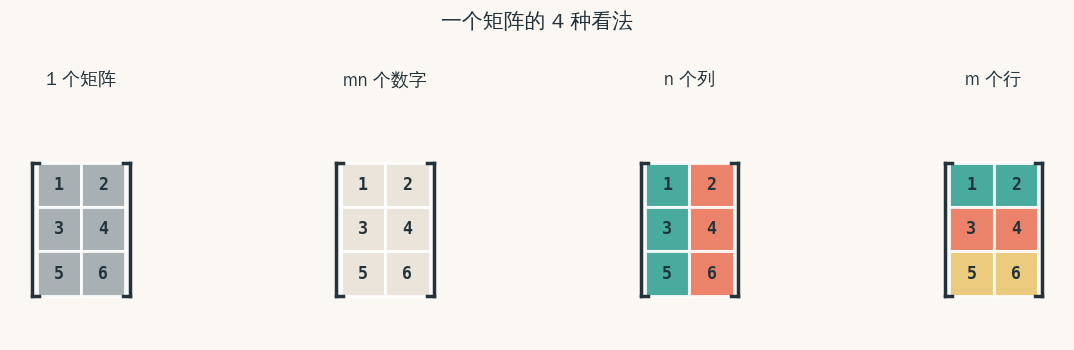

In [2]:
matrix_4ways(np.array([[1,2],[3,4],[5,6]]));

## 2. 向量 × 向量 — 2 种

- **(v1) 内积**：行 · 列 → 一个**标量**
- **(v2) 外积**：列 · 行 → 一个**秩 1 矩阵** ← 所有矩阵分解的积木

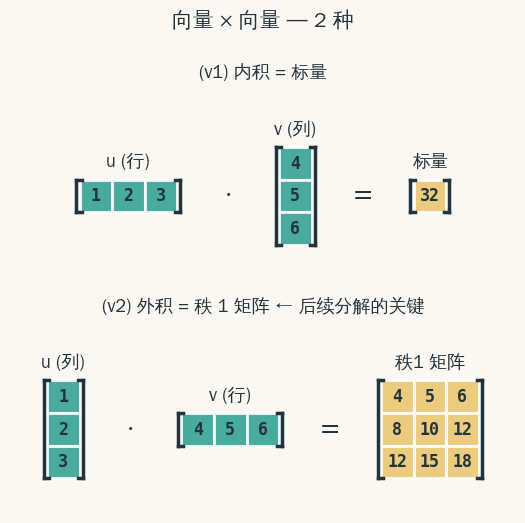

In [3]:
vec_times_vec([1,2,3], [4,5,6]);

**🔗 Aurora**：内积 = 余弦相似度的分子(推荐)；DFT 每个频点也是一次内积。外积(秩1)是连接 SVD / LoRA 的关键。


## 3. 矩阵 × 向量 — 2 种（最重要的一张图）

- **(Mv1)** 每行 · 向量 = 一组点积（dot product）
- **(Mv2)** 把结果看成 **A 的列向量的线性组合**——`Ax` 的灵魂。

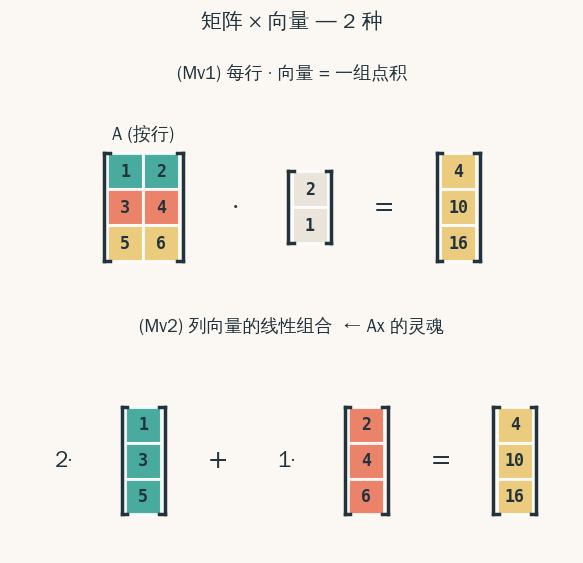

In [4]:
mat_times_vec(np.array([[1,2],[3,4],[5,6]]), [2,1]);

**✏️ 试试**：改变上面的 `[2,1]`，观察右边结果(金色)如何随"列的组合系数"变化。

**🔗 Aurora**：`aurora/audio/transforms.py` 里的 `dft(x)` 就是 `twiddle @ x`（第 64 行），`twiddle[k,n] = exp(-2πjkn/N)` 是 DFT 矩阵 W；`aurora/audio/mel.py` 里的 `mel_filterbank(...)` 返回滤波器矩阵 M，`M @ stft_output` 是同一张图在音频上的直接实例。

### 写代码前，先把变量表补完整

写 `mat_times_vec` 前明确三件事：
- 输入：矩阵 `A`（形状 `(m, n)`）和系数向量 `x`（长度 `n`）
- 关键步骤：分别计算 `A[:, k] * x[k]` 得到每列的贡献，再累加得到 `Ax`
- 返回：各列贡献的图形对象，用于并排展示「列的线性组合」

> **注**：`mat_times_vec` 已在 `aurora.laviz` 中实现，上面是理解其内部结构的概念预习，不需要学生自己编写。真正的编码练习在第 5 节「练习：实现 `classify_transform(A)`」。

## 4. 矩阵 × 矩阵 = 秩 1 矩阵之和

`AB = Σ_k (A 的第 k 列) × (B 的第 k 行)`，每项是一个秩 1 矩阵。

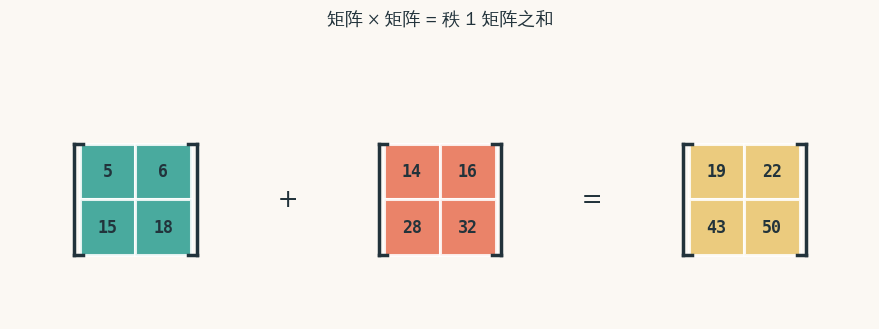

In [5]:
mat_times_mat_rank1(np.array([[1,2],[3,4]]), np.array([[5,6],[7,8]]));

**🔗 Aurora**：这正是 SVD `A=Σσ·uvᵀ`、谱定理 `S=Σλ·qqᵀ`、LoRA 低秩更新的同一张图。下一节（L20 · 矩阵分解图解） 把五大分解都画出来。

In [ ]:
A = np.array([[2.0, 1.0], [0.0, 1.0]])
probes = np.array([[1,0], [0,1], [1,1], [-1,2]], dtype=float)
print('矩阵 A 会怎样移动这些向量？')
for v in probes:
    out = A @ v
    print(f'{v} -> {out} | 长度 {np.linalg.norm(v):.2f} -> {np.linalg.norm(out):.2f}')


## 参数实验：用旋转矩阵（rotation matrix）验证正交矩阵保距

在第 3 节（`mat_times_vec`）的代码里，把矩阵替换成旋转矩阵（θ = 30°）：

```python
theta = np.radians(30)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
```

观察基向量 `[1,0]` 和 `[0,1]` 均被旋转 30°，但 `np.linalg.norm(R @ v) == np.linalg.norm(v)` 成立——这是**正交矩阵保距**的直观验证。对比原矩阵 `[[2,1],[0,1]]`：它同时改变方向和模长（非正交）。

In [ ]:
# ✅ 旋转 / 缩放 / 剪切 用 laviz 实际可视化（兑现标题承诺）
theta = np.radians(30)
R_30   = np.array([[np.cos(theta), -np.sin(theta)],   # 旋转 30°
                   [np.sin(theta),  np.cos(theta)]])
S_2    = np.array([[2., 0.], [0., 0.5]])              # x 放大 2×，y 缩小 0.5×
K_1    = np.array([[1., 1.], [0., 1.]])              # 水平剪切 k=1

v_unit = [1., 0.]
print('=== 旋转矩阵 R(30°) × [1,0] ===')
mat_times_vec(R_30, v_unit)
print('=== 缩放矩阵 S × [1,0] ===')
mat_times_vec(S_2, v_unit)
print('=== 剪切矩阵 K × [1,0] ===')
mat_times_vec(K_1, v_unit)


In [ ]:
import numpy as np

# 几何变换数学性质断言（独立运行，无需学生实现）
theta = np.radians(30)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
Refl = np.array([[0., 1.], [1., 0.]])
Scale = np.array([[2., 0.], [0., 0.5]])
Shear = np.array([[1., 1.], [0., 1.]])

# 旋转矩阵：正交 + det=+1 + 保长度
assert np.allclose(R @ R.T, np.eye(2), atol=1e-12), "旋转矩阵应满足 R@Rᵀ=I"
assert np.isclose(np.linalg.det(R), 1.0, atol=1e-12), "旋转矩阵 det 应为 +1"
v = np.array([3., 4.])
assert np.isclose(np.linalg.norm(R @ v), np.linalg.norm(v), atol=1e-12), "旋转保持向量长度"
print(f"旋转矩阵 ✅  R@Rᵀ=I, det={np.linalg.det(R):.4f}, ||R@v||=||v||={np.linalg.norm(v):.4f}")

# 反射矩阵：正交 + det=-1
assert np.allclose(Refl @ Refl.T, np.eye(2), atol=1e-12), "反射矩阵应满足 Refl@Reflᵀ=I"
assert np.isclose(np.linalg.det(Refl), -1.0, atol=1e-12), "反射矩阵 det 应为 -1"
print(f"反射矩阵 ✅  Refl@Reflᵀ=I, det={np.linalg.det(Refl):.4f}")

# 缩放矩阵：对角 + det = 对角元素之积
det_scale = np.linalg.det(Scale)
assert np.isclose(det_scale, Scale[0,0] * Scale[1,1], atol=1e-12), "缩放矩阵 det = 对角元素积"
assert np.isclose(Scale[0,1], 0.0) and np.isclose(Scale[1,0], 0.0), "缩放矩阵是对角矩阵"
print(f"缩放矩阵 ✅  det={det_scale:.4f} = {Scale[0,0]}×{Scale[1,1]}，纯对角结构")

# 剪切矩阵：det=1（保面积）但非正交
assert np.isclose(np.linalg.det(Shear), 1.0, atol=1e-12), "剪切矩阵保面积 det=1"
assert not np.allclose(Shear @ Shear.T, np.eye(2), atol=1e-4), "剪切矩阵不是正交矩阵"
print(f"剪切矩阵 ✅  det=1（保面积），但 K@Kᵀ≠I（改变角度）")
print("\n所有几何变换性质验证通过 ✅")

## 5. ✏️ 练习：实现 `classify_transform(A)`

给定一个 2×2 矩阵，判断它代表哪种几何变换：

- **rotation**（旋转）：`A @ Aᵀ ≈ I` 且 `det(A) ≈ +1`
- **reflection**（反射）：`A @ Aᵀ ≈ I` 且 `det(A) ≈ −1`
- **scaling**（缩放）：对角矩阵（`A[0,1] ≈ A[1,0] ≈ 0`）
- **shear**（剪切）：其他情况

**提示**：先算 `np.linalg.det(A)` 和 `A @ A.T`，再逐条判断。

**⚠️ 顺序很重要**：必须先判断正交性（步骤1 rotation，步骤2 reflection），再判断对角（步骤3 scaling）。若先检查对角，`[[0,1],[1,0]]` 也可能被误判——请严格按上述顺序实现。

In [ ]:
import numpy as np

def classify_transform(A, tol=1e-9):
    """返回 'rotation' | 'reflection' | 'scaling' | 'shear'"""
    A = np.asarray(A, float)
    # ✏️ TODO: 用 det + AᵀA 判断变换类型
    raise NotImplementedError('请实现 classify_transform')

# 验证
theta = np.pi / 3
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])   # 旋转 60°
Refl = np.array([[0., 1.], [1., 0.]])            # 沿 y=x 反射（det=-1，非对角，不会被误判为缩放）
Scale = np.array([[2., 0.], [0., 3.]])            # 各向异性缩放
Shear = np.array([[1., 1.], [0., 1.]])            # 剪切

try:
    assert classify_transform(R) == 'rotation',    f'旋转矩阵识别错误: {classify_transform(R)}'
    assert classify_transform(Refl) == 'reflection', f'反射矩阵识别错误: {classify_transform(Refl)}'
    assert classify_transform(Scale) == 'scaling',  f'缩放矩阵识别错误: {classify_transform(Scale)}'
    assert classify_transform(Shear) == 'shear',    f'剪切矩阵识别错误: {classify_transform(Shear)}'
    print('✅ 通过：旋转/反射/缩放/剪切 全部识别正确')
except NotImplementedError:
    print('⬆️  先把 classify_transform 实现完再运行')


## 本课收束

现在能用 `laviz` 把 `A @ x` 画成「A 的各列乘以 x 的系数再相加」，把 `A @ B` 画成若干秩1矩阵叠加。前者是矩阵×向量的列视角，后者是矩阵×矩阵的秩1分解视角——两者共享同一张图。这两张图在 Aurora 中对应 `mel_filterbank @ stft_output` 的频率映射和 DFT 矩阵 `W @ x` 的频谱计算。下一节（L20 · 矩阵分解图解） 会用同一套图语把 SVD 和特征分解展开，届时「秩1矩阵之和」的结构会直接复用。

In [ ]:
# ✏️ 本课自评
l19_review = {
    "matvec_picture_understood": None,  # 能解释 A@x 的列线性组合图？True/False
    "matmul_rank1_intuition":    None,  # 理解 A@B 的秩1叠加视角？True/False
    "classify_transform_done":   None,  # classify_transform 实现并通过断言？True/False
    "transform_det_sign":        None,  # 知道旋转 det=+1、反射 det=-1？True/False
}

unfilled = [k for k, v in l19_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l19_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L19 全部通关！进入 L20：矩阵分解图解')


---

→ **下一课**　[L20 · 分解图谱](L20_visual_factorizations.ipynb)

> 下节课将学习 **分解图谱**：LU / QR / SVD 三种分解的几何意义对比。